# 从像素到人脸特效
本笔记本用公开 NASA 示例完成真实推理。它不代表 LFW 测试或训练精度。按 Shift+Enter 逐格执行。

In [1]:
from pathlib import Path
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from app import Vision
print('Python:', sys.version.split()[0], 'OpenCV:', cv2.__version__)

Python: 3.12.14 OpenCV: 5.0.0


## 1 图像就是数字数组
彩色图像的形状是高×宽×3。OpenCV 的通道顺序是 BGR，显示前要换成 RGB。

彩色形状: (512, 512, 3) 灰度形状: (512, 512)


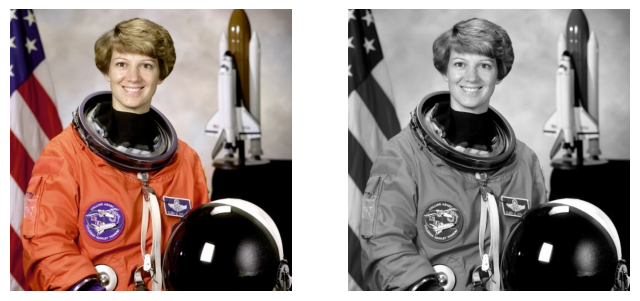

In [2]:
image = cv2.imread(str(ROOT / 'assets/sample.jpg'))
assert image is not None
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print('彩色形状:', image.shape, '灰度形状:', gray.shape)
fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)); ax[1].imshow(gray, cmap='gray')
for a in ax: a.axis('off')
plt.show()

## 2 检测和五个关键点
检测框给出位置，五个点给出姿态线索。看看转动图像以后，点是否仍跟随人脸。

检测到的人脸: 1
眼睛、鼻尖、嘴角: [[200.1929   101.88576 ]
 [247.08742  102.823654]
 [220.16925  124.56437 ]
 [198.47336  142.71964 ]
 [239.2993   143.62843 ]]


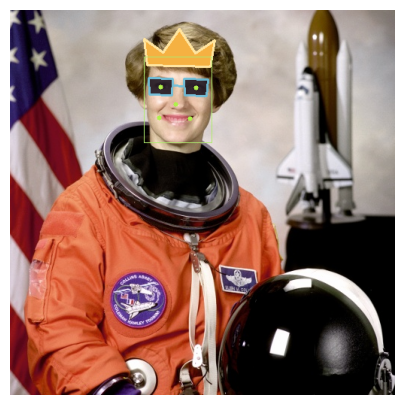

{'faces': 1, 'pipeline_ms': 65.08, 'pipeline_fps': 15.4, 'width': 512, 'height': 512, 'landmarks': [[[200.19290161132812, 101.88575744628906], [247.08741760253906, 102.82365417480469], [220.16925048828125, 124.56436920166016], [198.47335815429688, 142.71963500976562], [239.29930114746094, 143.62843322753906]]]}


In [3]:
vision = Vision(ROOT / 'models')
faces = vision.detect(image)
print('检测到的人脸:', len(faces))
print('眼睛、鼻尖、嘴角:', faces[0,4:14].reshape(5,2))
result, metrics = vision.process(image, 'all', .6, True)
plt.figure(figsize=(5,5)); plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()
print(metrics)

## 3 向量的余弦
点积除以两向量长度。相同方向为 1，垂直为 0，反向为 −1。

In [4]:
def cosine(a,b):
    a,b=np.asarray(a,float),np.asarray(b,float)
    return float(a@b/(np.linalg.norm(a)*np.linalg.norm(b)))
print(cosine([1,0],[1,0]), cosine([1,0],[0,1]), cosine([1,0],[-1,0]))
assert cosine([1,0],[0,1]) == 0
print(vision.verify(image,image,.363))

1.0 0.0 -1.0


{'cosine': 0.9999999331133438, 'threshold': 0.363, 'match': True, 'note': '阈值演示结果，不是身份认证或 LFW 准确率；应在独立验证集校准。'}


## 4 动手练习
1. 把特效改为 glasses、crown 或 lipstick。
2. 将图像旋转 10 度，再比较关键点。
3. 为什么一对相同图像通过验证，不能说明模型准确率是 100%？

答案：没有负样本、姿态/光照变化、独立测试集，也没有足够样本。LFW 实验必须执行 research.lfw 的完整协议。